In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from ase.units import kB
from flonacomldft.utils.io_utils import get_path
from flonacomldft.models.real_nvp import RealNVP_MLP
from flonacomldft.train_flow_from_data import train_flow

/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
lims = {'x_min':9.5, 'x_max':11., 'y_min':2.35, 'y_max':2.55}
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_plot(ax, n_points, target_log_prob, prop_log_prob=None, lims=lims):
    
    x_range = torch.linspace(lims['x_min'], lims['x_max'], n_points, device=device)

    if lims['y_min'] is None:
        y_range = x_range.clone()
    else:
        y_range = torch.linspace(lims['y_min'], lims['y_max'], n_points, device=device)

    grid = torch.meshgrid(x_range, y_range)
    xys = torch.stack(grid).reshape(2, n_points ** 2).T.to(device)

    Us_target = target_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

    if ax is None:
        plt.figure()
    else:
        plt.sca(ax)
    #plt.axis('off')

    plt.contourf(x_range, y_range, np.exp(Us_target)
    # np.log( - Us_target + Us_target.max() + 1)
    , 10, cmap='GnBu')
    ax.set_aspect('equal')

    if prop_log_prob is not None:
        Us_prop = prop_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

        plt.contour(x_range, y_range, np.exp(Us_prop), 10, colors='k', linestyles=':', alpha=0.5)


In [3]:
def from_popt_to_gauss_params(popt):
    means = popt[:2]
    inv_cov = popt[2:-1].reshape(2, 2)
    cov = np.linalg.inv(inv_cov)
    norm = popt[-1]
    return means, cov, norm

def gaussian2d(XY, x0, y0, sigma_xx, sigma_xy, sigma_yx, sigma_yy, A):
    XY = XY.T
    XY = torch.tensor(XY, dtype=torch.float64, device=device)
    dx = XY[0] - x0
    dy = XY[1] - y0
    covariance_xx = sigma_xx * dx
    covariance_xy = sigma_xy * dx
    covariance_yx = sigma_yx * dy
    covariance_yy = sigma_yy * dy
    exponent = -0.5 * (covariance_xx * dx + covariance_xy * dy + covariance_yx * dx + covariance_yy * dy)
    return A * torch.exp(exponent)

class TargetGaussian:
    def __init__(self, mean, cov, norm, kB=kB, T=300):
        self.kB = kB
        self.T = T
        self.norm = norm
        self.mean = mean
        self.cov = cov
        self.inv_cov = np.linalg.inv(cov)
        self.popt = np.hstack([self.mean.flatten(), self.inv_cov.flatten(), self.norm])
    
    def sample(self, n_samples):
        samples = np.random.multivariate_normal(self.mean, self.cov, n_samples)
        return torch.tensor(samples, dtype=torch.float64)

    def prob(self, x):
        return torch.tensor(gaussian2d(x, *self.popt)).detach()

    def log_prob(self, x):
        return torch.log(gaussian2d(x, *self.popt)).detach()
    
    def U(self, x):
        return -self.log_prob(x)*(self.T*self.kB)

In [4]:
params_popt_is0 = np.load(get_path()+'/params_fit_fes/mode_0.npy')

In [5]:
popt_0, popt_vert, popt_gen = params_popt_is0

In [6]:
target_0 = TargetGaussian(*from_popt_to_gauss_params(popt_vert))#popt_0))
vert = TargetGaussian(*from_popt_to_gauss_params(popt_vert))
generator = TargetGaussian(*from_popt_to_gauss_params(popt_gen))

In [7]:
n_samples = 100

generator_samples = generator.sample(n_samples)
generator_us = torch.tensor([target_0.U(sample) for sample in generator_samples])
id_mode = torch.zeros(n_samples)
dataset = torch.cat([generator_samples.T, generator_us.reshape(1, -1), id_mode.reshape(1, -1)]).T

# use mean to center data
dataset[:,:2] = dataset[:, :2] # - torch.tensor([mean_0])

train = dataset[:int(0.8 * len(dataset))].float()
test = dataset[int(0.8 * len(dataset)):].float() 

#train = train.type(torch.float32)
#test = test.type(torch.float32)

/tmp/ipykernel_566050/2067620633.py:31: RuntimeWarning: covariance is not positive-semidefinite.
  samples = np.random.multivariate_normal(self.mean, self.cov, n_samples)
/tmp/ipykernel_566050/2067620633.py:9: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matricesor `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2981.)
  XY = XY.T
/tmp/ipykernel_566050/2067620633.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)


In [8]:
target_energy = lambda x: target_0.U(x)
mlp_dic = {'model': target_energy}

In [9]:
cov_init = torch.cov(train[:, :2].T).float()

n_blocks = 6
hidden_dim = 64
hidden_depth = 4

model = RealNVP_MLP(2,
                    n_blocks=n_blocks,
                    block_depth=1,
                    init_weight_scale=1e-1,
                    base_cov=cov_init,
                    hidden_dim=hidden_dim,
                    hidden_depth=hidden_depth,
                    device=device,
                    )

n_iter = 1000
lr = 1e-3

In [10]:
flow_dic = train_flow(
    model,
    train,
    test,
    dim=2,
    n_iter=n_iter,
    lr=1e-3,
    use_scheduler=True,
    step_schedule=int(n_iter/2),
    save_splits=10,
    grad_clip=1e4,
    with_tqdm=False,
    compute_part_ratio=True,
    energy_type='mlp',
    mlp_model=mlp_dic['model'],
    n_prop=1000,
    path='',
)

/tmp/ipykernel_566050/2067620633.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)


t=0.0e+00 	 loss: 49944.49	Gd: 1e+04	lr: 1.00e-03	part ratio: nan
t=1.0e+02 	 loss: 148.20	Gd: 6e+02	lr: 1.00e-03	part ratio: nan
t=2.0e+02 	 loss: 0.58	Gd: 8e+00	lr: 1.00e-03	part ratio: 1.57e-02
t=3.0e+02 	 loss: 0.40	Gd: 9e+00	lr: 1.00e-03	part ratio: 1.61e-02
t=4.0e+02 	 loss: 0.22	Gd: 8e+00	lr: 1.00e-03	part ratio: 1.21e-02
t=5.0e+02 	 loss: 0.04	Gd: 7e+00	lr: 5.00e-04	part ratio: 7.48e-02
t=6.0e+02 	 loss: -0.05	Gd: 7e+00	lr: 5.00e-04	part ratio: 1.86e-03
t=7.0e+02 	 loss: -0.14	Gd: 7e+00	lr: 5.00e-04	part ratio: 1.42e-02
t=8.0e+02 	 loss: -0.24	Gd: 6e+00	lr: 5.00e-04	part ratio: 8.58e-02
t=9.0e+02 	 loss: -0.33	Gd: 6e+00	lr: 5.00e-04	part ratio: 1.69e-02


In [11]:
from flonacomldft.utils.plots import set_plot_iteration

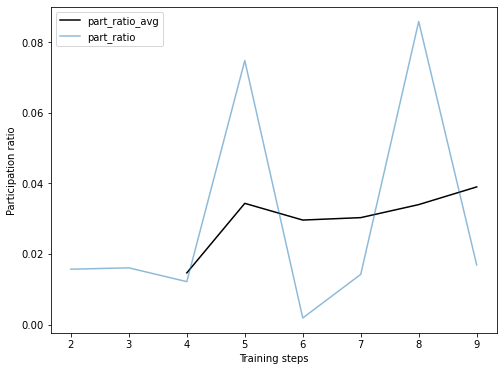

In [12]:
fig, ax = plt.subplots(1,1, figsize=(8,6))
set_plot_iteration(flow_dic['part_ratios'].detach(), avg=True, window_size=3, axis=1, ax=ax, label='part_ratio')
ax.set_xlabel('Training steps')
ax.set_ylabel('Participation ratio')
ax.legend()

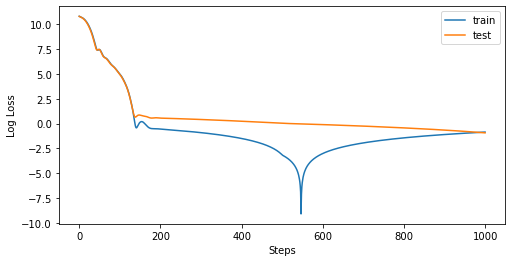

In [13]:
losses_train = abs(flow_dic['losses'][0])
losses_test = abs(flow_dic['losses'][1])

fig, ax = plt.subplots(1, 1, figsize=(8,4) )
set_plot_iteration(torch.log(losses_train), avg=False, window_size=10, axis=0, alpha=1, ax=ax, label='train')
set_plot_iteration(torch.log(losses_test), avg=False, window_size=10, axis=0,alpha=1, ax=ax, label='test')

ax.set_xlabel('Steps')
ax.set_ylabel('Log Loss')
ax.set_label(['train', 'test'])
ax.legend()    

/tmp/ipykernel_566050/2067620633.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)
/tmp/ipykernel_566050/2067620633.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(gaussian2d(x, *self.popt)).detach()
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


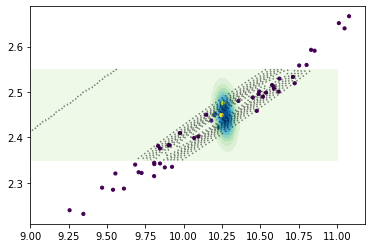

In [14]:
model = flow_dic['model']
flow_samples = model.sample(50) #+ torch.tensor(generator.mean).reshape(1, -1)
prob_samples = target_0.prob(flow_samples)

flowlogprob = lambda x: -flow_dic['model'].nll(x)

fig, ax = plt.subplots(1, 1)
lims = {'x_min':9, 'x_max':11, 'y_min':2.35, 'y_max':2.55}

set_plot(ax, 100, target_0.log_prob, flowlogprob, lims)
ax.scatter(flow_samples[:, 0].detach().numpy(), flow_samples[:, 1].detach().numpy(), c=prob_samples, s=10)
plt.gca().set_aspect('auto')

In [15]:
from flonacomldft.full_adaptive_sampling import adaptive_sampling
from flonacomldft.full_adaptive_sampling import get_weights

In [16]:
flow_hyperparams = {'n_iter': 10,
    'lr': 2.5e-4,
    'use_scheduler': False,
    'step_schedule': 100,
    'save_splits': 10,
    'grad_clip': 1e4}

In [17]:
n_runs = 5
n_chains = 25
n_steps = 5

init_samples = generator.sample(n_chains)
init_us = target_0.U(init_samples)
init_id_mode = torch.zeros(init_samples.shape[0])

print(init_id_mode)

init_mcmc = torch.cat([init_samples.T, init_us.reshape(1, -1), init_id_mode.reshape(1, -1)]).T

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.])


/tmp/ipykernel_566050/2067620633.py:31: RuntimeWarning: covariance is not positive-semidefinite.
  samples = np.random.multivariate_normal(self.mean, self.cov, n_samples)
/tmp/ipykernel_566050/2067620633.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)


In [18]:
full_train = torch.cat([train])
full_test = torch.cat([test])

flows_dic = [flow_dic]
mlps_dic = [mlp_dic]

In [19]:
full_train = full_train.type(torch.float32)
full_test = full_test.type(torch.float32)
init_mcmc = init_mcmc.type(torch.float32)

In [ ]:
_ = adaptive_sampling(full_train, 
                        full_test,
                         init_mcmc, 
                         dim=2,
                         dict_flows_init=flows_dic,
                         dict_mlps_init=mlps_dic,
                         mixture=False,
                         flow_hyperparams=[flow_hyperparams],
                         n_runs=n_runs,
                         n_chains=n_chains,
                         n_steps=n_steps,
                         path='',
                        )

/tmp/ipykernel_566050/2067620633.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)


step: 0 	 acc: 0.16
step: 1 	 acc: 0.16
step: 2 	 acc: 0.32
step: 3 	 acc: 0.16
step: 4 	 acc: 0.16
t=0.0e+00 	 loss: -1.46	Gd: 2e+01	lr: 2.50e-04	